In [885]:
import pandas as pd
df = pd.read_csv(r"/content/EmployeeAttrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [886]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [887]:
df.shape

(1470, 35)

In [888]:
df.columns[df.nunique()==1]

Index(['EmployeeCount', 'Over18', 'StandardHours'], dtype='object')

In [889]:
df.drop(columns=["EmployeeCount","Over18","StandardHours","EmployeeNumber"],inplace=True)
df.shape

(1470, 31)

In [890]:
df.drop_duplicates(inplace=True)
df.shape

(1470, 31)

In [891]:
df.isnull().sum().sum()

np.int64(0)

In [892]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [893]:
x = df.drop(columns=["Attrition"])
y = df["Attrition"]

In [894]:
x.shape,y.shape

((1470, 30), (1470,))

In [895]:
x.dtypes

,0
Age,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,object
HourlyRate,int64


In [896]:
label_map = {"BusinessTravel":{"Travel_Rarely":1,"Travel_Frequently":2,"Non-Travel":0}}
x.replace(label_map,inplace=True)


/tmp/ipykernel_4699/1548427345.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x.replace(label_map,inplace=True)


In [897]:
x["BusinessTravel"].unique()

array([1, 2, 0])

In [898]:
x_ohe = pd.get_dummies(x)
x_ohe.shape

(1470, 49)

In [899]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_ohe,y,test_size=0.3,random_state=7,stratify=y)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1029, 49), (441, 49), (1029,), (441,))

In [900]:
con_col = x_train.columns[x_train.nunique()>15]
con_col

Index(['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome',
       'MonthlyRate', 'TotalWorkingYears', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [901]:
cat_col = x_train.columns[x_train.nunique()<=15]
cat_col

Index(['BusinessTravel', 'Education', 'EnvironmentSatisfaction',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'Department_Human Resources', 'Department_Research & Development',
       'Department_Sales', 'EducationField_Human Resources',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male',
       'JobRole_Healthcare Representative', 'JobRole_Human Resources',
       'JobRole_Laboratory Technician', 'JobRole_Manager',
       'JobRole_Manufacturing Director', 'JobRole_Research Director',
       'JobRole_Research Scientist', 'JobRole_Sales Executive',
       'JobRole_Sales Representative', 'MaritalStatus_Divorced',
       'MaritalStatus_Married', 'MaritalStatus_

In [902]:
# Outlier Detection
# Z-score
# IQR

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(x_train)
x_train_sc = sc.transform(x_train)
x_test_sc = sc.transform(x_test)



In [903]:
# detect outlier based z-score
def outlier_detection_zc(df, col):
  print("Outliers in Column ->",col)
  o_count = df.loc[(df[col]<-3)|(df[col]>3),col].shape[0]
  print(o_count)

In [904]:
import pandas as pd
x_train_sc = pd.DataFrame(x_train_sc,columns=x_train.columns)
for col in con_col:
  outlier_detection_zc(x_train_sc,col)

Outliers in Column -> Age
0
Outliers in Column -> DailyRate
0
Outliers in Column -> DistanceFromHome
0
Outliers in Column -> HourlyRate
0
Outliers in Column -> MonthlyIncome
0
Outliers in Column -> MonthlyRate
0
Outliers in Column -> TotalWorkingYears
14
Outliers in Column -> YearsAtCompany
19
Outliers in Column -> YearsInCurrentRole
11
Outliers in Column -> YearsSinceLastPromotion
26
Outliers in Column -> YearsWithCurrManager
8


In [905]:
# Outlier detection using IQR
def outlier_detection_iqr(df,col):
  print("Outliers in Column ->",col)
  q1,q3 = df[col].quantile([0.25,0.75])
  iqr = q3-q1
  lower_bound = q1 - (1.5*iqr)
  upper_bound = q3 + (1.5*iqr)
  o_count = df.loc[(df[col]<lower_bound)|(df[col]>upper_bound),col].shape[0]
  print(o_count)


In [906]:
for col in con_col:
  outlier_detection_iqr(x_train_sc,col)

Outliers in Column -> Age
0
Outliers in Column -> DailyRate
0
Outliers in Column -> DistanceFromHome
0
Outliers in Column -> HourlyRate
0
Outliers in Column -> MonthlyIncome
69
Outliers in Column -> MonthlyRate
0
Outliers in Column -> TotalWorkingYears
45
Outliers in Column -> YearsAtCompany
69
Outliers in Column -> YearsInCurrentRole
11
Outliers in Column -> YearsSinceLastPromotion
73
Outliers in Column -> YearsWithCurrManager
8


In [907]:
def remove_outlier_zc(df,col):
  df1 = df.copy()
  print("Column-->",col)
  print("Before Removing Outliers",df1.shape[0])
  df1 = df1.loc[(df1[col]>=-3)&(df1[col]<=3),:]
  print("After Removing Outliers",df1.shape[0])
  return df1

In [908]:
x_train_sc_or = x_train_sc.copy()
for col in con_col:
  x_train_sc_or = remove_outlier_zc(x_train_sc_or,col)

Column--> Age
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> DailyRate
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> DistanceFromHome
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> HourlyRate
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> MonthlyIncome
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> MonthlyRate
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> TotalWorkingYears
Before Removing Outliers 1029
After Removing Outliers 1015
Column--> YearsAtCompany
Before Removing Outliers 1015
After Removing Outliers 1000
Column--> YearsInCurrentRole
Before Removing Outliers 1000
After Removing Outliers 992
Column--> YearsSinceLastPromotion
Before Removing Outliers 992
After Removing Outliers 976
Column--> YearsWithCurrManager
Before Removing Outliers 976
After Removing Outliers 972


In [909]:
def remove_outlier_iqr(df,col):
  df2 = df.copy()

  q1,q3 = df2[col].quantile([0.25,0.75])
  iqr = q3-q1
  lower_bound = q1 - (1.5*iqr)
  upper_bound = q3 + (1.5*iqr)
  print("Column-->",col)
  print("Before Removing Outliers",df2.shape[0])
  df2 = df2.loc[(df2[col]>=lower_bound)&(df2[col]<=upper_bound),:]
  print("After Removing Outliers",df2.shape[0])
  return df2

In [910]:
x_train_or = x_train_sc.copy()
for col in con_col:
  x_train_or = remove_outlier_iqr(x_train_or,col)

Column--> Age
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> DailyRate
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> DistanceFromHome
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> HourlyRate
Before Removing Outliers 1029
After Removing Outliers 1029
Column--> MonthlyIncome
Before Removing Outliers 1029
After Removing Outliers 960
Column--> MonthlyRate
Before Removing Outliers 960
After Removing Outliers 960
Column--> TotalWorkingYears
Before Removing Outliers 960
After Removing Outliers 912
Column--> YearsAtCompany
Before Removing Outliers 912
After Removing Outliers 895
Column--> YearsInCurrentRole
Before Removing Outliers 895
After Removing Outliers 893
Column--> YearsSinceLastPromotion
Before Removing Outliers 893
After Removing Outliers 793
Column--> YearsWithCurrManager
Before Removing Outliers 793
After Removing Outliers 782


In [911]:
def outlier_impute_zc(df,col):
  df1 = df.copy()
  print("Column-->",col)
  df1.loc[(df1[col]<-3),col] = -3
  df1.loc[(df1[col]>3),col] = 3
  print(df1[col].min(),df1[col].max())
  return df1

In [912]:
x_train_sc_io = x_train_sc.copy()
for col in con_col:
  x_train_sc_io = outlier_impute_zc(x_train_sc_io,col)

Column--> Age
-2.0460451710081347 2.529447957452466
Column--> DailyRate
-1.7174708636889437 1.7349192671167921
Column--> DistanceFromHome
-0.997432893693513 2.5308711619353996
Column--> HourlyRate
-1.778655035046836 1.6591457585352494
Column--> MonthlyIncome
-1.1619324653374639 2.9272683827988875
Column--> MonthlyRate
-1.7231722576056423 1.771638064367085
Column--> TotalWorkingYears
-1.4235994340147937 3.0
Column--> YearsAtCompany
-1.1539443619793066 3.0
Column--> YearsInCurrentRole
-1.195567661761814 3.0
Column--> YearsSinceLastPromotion
-0.676713965401559 3.0
Column--> YearsWithCurrManager
-1.1714142612068223 3.0


In [913]:
from numpy._core.defchararray import lower
def outlier_impute_iqr(df,col):
  df1 = df.copy()
  print("Column-->",col)
  q1,q3 = df1[col].quantile([0.25,0.75])
  iqr = q3-q1
  lower_bound = q1 - (1.5*iqr)
  upper_bound = q3 + (1.5*iqr)
  df1.loc[(df1[col]<lower_bound),col] = lower_bound
  df1.loc[(df1[col]>upper_bound),col] = upper_bound
  print(lower_bound,upper_bound,df1[col].min(),df1[col].max())
  return df1

In [914]:
x_train_sc_io = x_train_sc.copy()
for col in con_col:
  x_train_sc_io = outlier_impute_iqr(x_train_sc_io,col)

Column--> Age
-2.863097515376099 2.801798738908454 -2.0460451710081347 2.529447957452466
Column--> DailyRate
-3.4139892230963476 3.4907910385151255 -1.7174708636889437 1.7349192671167921
Column--> DistanceFromHome
-2.9506012102023753 2.5938765915002016 -0.997432893693513 2.5308711619353996
Column--> HourlyRate
-3.5466668717461944 3.5253804750512385 -1.778655035046836 1.6591457585352494
Column--> MonthlyIncome
-2.574630174500368 2.2287361033463613 -1.1619324653374639 2.2287361033463613
Column--> MonthlyRate
-3.4339524238505934 3.4178684314509256 -1.7231722576056423 1.771638064367085
Column--> TotalWorkingYears
-2.3825440645471474 2.2203901620081488 -1.4235994340147937 2.2203901620081488
Column--> YearsAtCompany
-2.1588036695759554 1.8606335608106397 -1.1539443619793066 1.8606335608106397
Column--> YearsInCurrentRole
-2.769129331934137 2.9529131050561275 -1.195567661761814 2.9529131050561275
Column--> YearsSinceLastPromotion
-2.099749395370641 1.6950117512135783 -0.676713965401559 1.6950

In [915]:
x_train.mean()

,0
Age,36.781341
BusinessTravel,1.102041
DailyRate,797.472303
DistanceFromHome,8.915452
Education,2.921283
EnvironmentSatisfaction,2.728863
HourlyRate,66.216715
JobInvolvement,2.719145
JobLevel,2.040816
JobSatisfaction,2.719145


In [916]:
# apply PCA

from sklearn.decomposition import PCA
pca = PCA(random_state=7) #all possible components
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
x_train_pca.shape, x_test_pca.shape


((1029, 49), (441, 49))

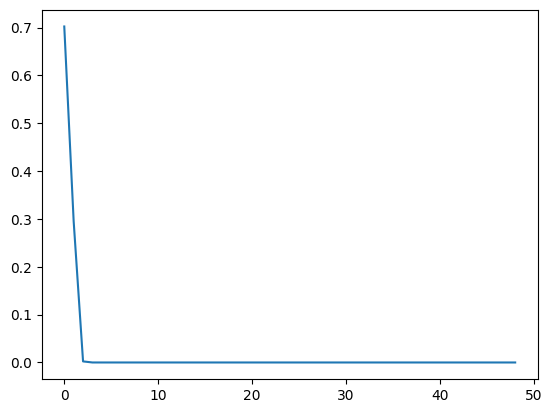

In [917]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)),pca.explained_variance_ratio_)

In [918]:
# apply PCA

from sklearn.decomposition import PCA
pca = PCA(random_state=7) #all possible components
x_train_pca = pca.fit_transform(x_train_sc)
x_test_pca = pca.transform(x_test_sc)
x_train_pca.shape, x_test_pca.shape

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


((1029, 49), (441, 49))

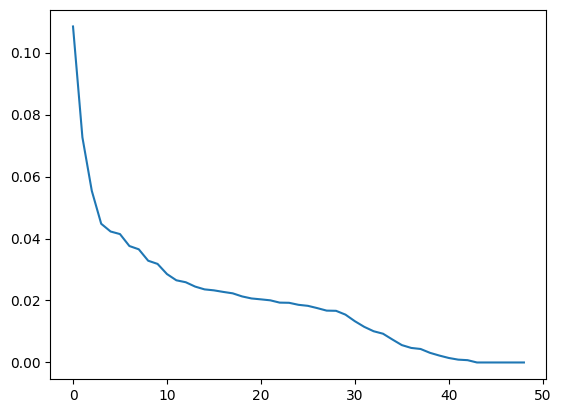

In [919]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)),pca.explained_variance_ratio_)

In [920]:
pca.explained_variance_ratio_

array([1.08423844e-01, 7.26508683e-02, 5.53801487e-02, 4.47591141e-02,
       4.22618996e-02, 4.14326857e-02, 3.75805218e-02, 3.65224376e-02,
       3.28370936e-02, 3.18078455e-02, 2.85347516e-02, 2.65198316e-02,
       2.58922827e-02, 2.44863065e-02, 2.35889060e-02, 2.32749099e-02,
       2.27668322e-02, 2.23118664e-02, 2.13132298e-02, 2.06581513e-02,
       2.03699587e-02, 2.00564644e-02, 1.93148529e-02, 1.92585661e-02,
       1.86080882e-02, 1.82794829e-02, 1.75433901e-02, 1.67348832e-02,
       1.66704326e-02, 1.54416424e-02, 1.33230121e-02, 1.14993815e-02,
       1.00801405e-02, 9.28311261e-03, 7.41362987e-03, 5.61221961e-03,
       4.69592371e-03, 4.35467626e-03, 3.11272351e-03, 2.22887748e-03,
       1.45351501e-03, 9.17395201e-04, 7.44104344e-04, 5.51603757e-18,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00])

In [921]:
# apply PCA

from sklearn.decomposition import PCA
pca = PCA(n_components = 0.9,random_state=7) #all possible components
x_train_pca = pca.fit_transform(x_train_sc_io)
x_test_pca = pca.transform(x_test)
x_train_pca.shape, x_test_pca.shape

((1029, 29), (441, 29))

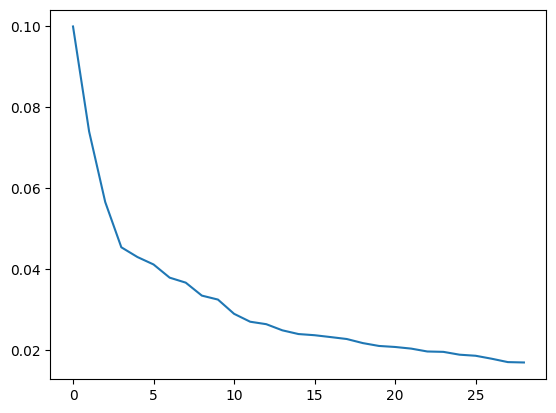

In [922]:
import matplotlib.pyplot as plt
plt.plot(range(len(pca.components_)),pca.explained_variance_ratio_)

In [923]:
pca.explained_variance_ratio_

array([0.0998557 , 0.07394146, 0.05654775, 0.04538511, 0.04298265,
       0.04114904, 0.03789698, 0.03666114, 0.03346598, 0.0324871 ,
       0.02897615, 0.0270221 , 0.02641749, 0.02490052, 0.02398399,
       0.02369643, 0.02323489, 0.02275793, 0.02175008, 0.02104629,
       0.02079517, 0.02039115, 0.01968182, 0.01958912, 0.01889149,
       0.01862777, 0.01789306, 0.01706266, 0.01697029])

In [924]:
# 1. Outlier imputation is more efficient outlier removal
# 2. PCA requires Standardize data
# 3. PCA is affected by Outliers so, use after outliers imputation
# 4. there are many components in PCA with explained variance = 0
# 5. Using n_components as 0.9/0.95,0.99 is better than fixed number
# 6. Outlier imputation IQR is better than z-score

In [925]:
# kernal PCA


In [926]:
import pandas as pd
df = pd.read_csv(r"/content/ev_charging_patterns.csv")
df

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,User_1316,Nissan Leaf,100.000000,Station_57,New York,2024-02-24 19:00:00,2024-02-24 20:30:00,42.011654,1.426444,5.895475,22.081164,Evening,Sunday,39.204102,83.915952,239.601075,1.919655,7.0,DC Fast Charger,Commuter
1316,User_1317,BMW i3,100.000000,Station_40,New York,2024-02-24 20:00:00,2024-02-24 20:44:00,68.185853,3.238212,18.388012,5.067806,Evening,Tuesday,31.456375,93.096461,164.376022,34.029775,4.0,Level 2,Casual Driver
1317,User_1318,Nissan Leaf,100.000000,Station_374,New York,2024-02-24 21:00:00,2024-02-24 23:03:00,18.895102,3.267122,45.482066,37.255002,Evening,Tuesday,71.903081,78.678879,226.519258,20.358761,5.0,DC Fast Charger,Commuter
1318,User_1319,Chevy Bolt,85.000000,Station_336,San Francisco,2024-02-24 22:00:00,2024-02-24 23:20:00,13.756252,2.754527,38.148183,39.046146,Afternoon,Sunday,76.187997,65.926573,291.494076,24.134598,5.0,Level 2,Commuter


In [927]:
df.dropna()

,User ID,Vehicle Model,Battery Capacity (kWh),Charging Station ID,Charging Station Location,Charging Start Time,Charging End Time,Energy Consumed (kWh),Charging Duration (hours),Charging Rate (kW),Charging Cost (USD),Time of Day,Day of Week,State of Charge (Start %),State of Charge (End %),Distance Driven (since last charge) (km),Temperature (°C),Vehicle Age (years),Charger Type,User Type
0,User_1,BMW i3,108.463007,Station_391,Houston,2024-01-01 00:00:00,2024-01-01 00:39:00,60.712346,0.591363,36.389181,13.087717,Evening,Tuesday,29.371576,86.119962,293.602111,27.947953,2.0,DC Fast Charger,Commuter
1,User_2,Hyundai Kona,100.000000,Station_428,San Francisco,2024-01-01 01:00:00,2024-01-01 03:01:00,12.339275,3.133652,30.677735,21.128448,Morning,Monday,10.115778,84.664344,112.112804,14.311026,3.0,Level 1,Casual Driver
2,User_3,Chevy Bolt,75.000000,Station_181,San Francisco,2024-01-01 02:00:00,2024-01-01 04:48:00,19.128876,2.452653,27.513593,35.667270,Morning,Thursday,6.854604,69.917615,71.799253,21.002002,2.0,Level 2,Commuter
3,User_4,Hyundai Kona,50.000000,Station_327,Houston,2024-01-01 03:00:00,2024-01-01 06:42:00,79.457824,1.266431,32.882870,13.036239,Evening,Saturday,83.120003,99.624328,199.577785,38.316313,1.0,Level 1,Long-Distance Traveler
4,User_5,Hyundai Kona,50.000000,Station_108,Los Angeles,2024-01-01 04:00:00,2024-01-01 05:46:00,19.629104,2.019765,10.215712,10.161471,Morning,Saturday,54.258950,63.743786,203.661847,-7.834199,1.0,Level 1,Long-Distance Traveler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,User_1316,Nissan Leaf,100.000000,Station_57,New York,2024-02-24 19:00:00,2024-02-24 20:30:00,42.011654,1.426444,5.895475,22.081164,Evening,Sunday,39.204102,83.915952,239.601075,1.919655,7.0,DC Fast Charger,Commuter
1316,User_1317,BMW i3,100.000000,Station_40,New York,2024-02-24 20:00:00,2024-02-24 20:44:00,68.185853,3.238212,18.388012,5.067806,Evening,Tuesday,31.456375,93.096461,164.376022,34.029775,4.0,Level 2,Casual Driver
1317,User_1318,Nissan Leaf,100.000000,Station_374,New York,2024-02-24 21:00:00,2024-02-24 23:03:00,18.895102,3.267122,45.482066,37.255002,Evening,Tuesday,71.903081,78.678879,226.519258,20.358761,5.0,DC Fast Charger,Commuter
1318,User_1319,Chevy Bolt,85.000000,Station_336,San Francisco,2024-02-24 22:00:00,2024-02-24 23:20:00,13.756252,2.754527,38.148183,39.046146,Afternoon,Sunday,76.187997,65.926573,291.494076,24.134598,5.0,Level 2,Commuter


In [928]:
df.isnull().sum()

,0
User ID,0
Vehicle Model,0
Battery Capacity (kWh),0
Charging Station ID,0
Charging Station Location,0
Charging Start Time,0
Charging End Time,0
Energy Consumed (kWh),66
Charging Duration (hours),0
Charging Rate (kW),66


In [929]:
df.dtypes

,0
User ID,object
Vehicle Model,object
Battery Capacity (kWh),float64
Charging Station ID,object
Charging Station Location,object
Charging Start Time,object
Charging End Time,object
Energy Consumed (kWh),float64
Charging Duration (hours),float64
Charging Rate (kW),float64


In [930]:
df.nunique()

,0
User ID,1320
Vehicle Model,5
Battery Capacity (kWh),147
Charging Station ID,462
Charging Station Location,5
Charging Start Time,1320
Charging End Time,1309
Energy Consumed (kWh),1254
Charging Duration (hours),1320
Charging Rate (kW),1254


In [931]:
df.drop(columns=["User ID","Charging Station ID","Charging Start Time","Charging End Time"],inplace=True)
df.shape

(1320, 16)

In [932]:
df.drop_duplicates(inplace=True)
df.shape

(1320, 16)

In [933]:
df.dropna(inplace=True)

In [934]:
df.shape

(1131, 16)

In [935]:
df_ohe = pd.get_dummies(df)

In [936]:
df_ohe.shape

(1131, 37)

In [937]:
x = df_ohe

In [938]:
from sklearn.model_selection import train_test_split
x_train,x_test = train_test_split(x,test_size=0.3,random_state=7)
x_train.shape,x_test.shape

((791, 37), (340, 37))

In [939]:
x_train = (x_train-x_train.mean())/x_train.std()
x_test = (x_test-x_train.mean())/x_train.std()

In [940]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(kernel="poly",degree=2,random_state=7)
kpca.fit(x_train)

KernelPCA(degree=2, kernel='poly', random_state=7)

In [941]:
kpca.eigenvalues_.shape

(474,)

In [942]:
from sklearn.decomposition import KernelPCA
kpca = KernelPCA(kernel="rbf",random_state=7)
kpca.fit(x_train)

KernelPCA(kernel='rbf', random_state=7)

In [943]:
kpca.eigenvalues_.shape

(790,)

In [944]:
from numpy._core.defchararray import lower
def outlier_impute_iqr(df,col):
  df1 = df.copy()
  print("Column-->",col)
  q1,q3 = df1[col].quantile([0.25,0.75])
  iqr = q3-q1
  lower_bound = q1 - (1.5*iqr)
  upper_bound = q3 + (1.5*iqr)
  df1.loc[(df1[col]<lower_bound),col] = lower_bound
  df1.loc[(df1[col]>upper_bound),col] = upper_bound
  print(lower_bound,upper_bound,df1[col].min(),df1[col].max())
  return df1

In [945]:
con_col = x_train.columns[x_train.nunique()>15]
con_col

Index(['Battery Capacity (kWh)', 'Energy Consumed (kWh)',
       'Charging Duration (hours)', 'Charging Rate (kW)',
       'Charging Cost (USD)', 'State of Charge (Start %)',
       'State of Charge (End %)', 'Distance Driven (since last charge) (km)',
       'Temperature (°C)', 'Vehicle Age (years)'],
      dtype='object')

In [946]:
x_train_io = x_train.copy()
for col in con_col:
  x_train_io = outlier_impute_iqr(x_train_io,col)

Column--> Battery Capacity (kWh)
-2.3241696227235886 2.228495421995734 -2.3241696227235886 2.228495421995734
Column--> Energy Consumed (kWh)
-3.3271059378496632 3.3446660603796365 -1.950026882211301 3.3446660603796365
Column--> Charging Duration (hours)
-3.2682970989850366 3.2263772904346064 -2.0676213924362337 3.2263772904346064
Column--> Charging Rate (kW)
-3.309043836822947 3.264113001800868 -1.7479735039452566 3.264113001800868
Column--> Charging Cost (USD)
-3.4218791643536455 3.4333135841573217 -1.9756361885336213 3.4333135841573217
Column--> State of Charge (Start %)
-3.4419401990972824 3.39951514063654 -1.9107112674418218 3.041918129848564
Column--> State of Charge (End %)
-3.1149311902721966 3.1267312251564077 -3.1149311902721966 3.1267312251564077
Column--> Distance Driven (since last charge) (km)
-3.4765358075685264 3.5057930797496843 -1.7746298502964073 2.8085617566921934
Column--> Temperature (°C)
-3.304466717677972 3.325483864301752 -1.744866625970943 3.325483864301752
Col

In [947]:
kpca.eigenvalues_.shape

(790,)